## Imports

In [1]:
import os
from pathlib import Path

import mne

## Set current dir to project root dir

In [2]:
def find_project_root():
    """Walk up from CWD until we find the project root."""
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())

## Main

In [3]:
# Path to your header file
file_path = "./ds006018/sub-001/eeg/sub-001_task-flanker_eeg.vhdr"

In [4]:
# Load the raw data
# preload=True loads data into RAM, allowing for faster processing/editing
raw = mne.io.read_raw_brainvision(file_path, preload=True)

Extracting parameters from ./ds006018/sub-001/eeg/sub-001_task-flanker_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 396329  =      0.000 ...   792.658 secs...


/tmp/ipykernel_1298737/1918545080.py:3: RuntimeWarning: No coordinate information found for channels ['HEL', 'LM', 'RM', 'HER', 'VER']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(file_path, preload=True)
/tmp/ipykernel_1298737/1918545080.py:3: RuntimeWarning: Not setting positions of 5 misc channels found in montage:
['HEL', 'LM', 'RM', 'HER', 'VER']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(file_path, preload=True)


In [5]:
# Print basic info (Sampling rate, number of channels, etc.)
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, HEL, FC5, FC1, C3, T7, LM, CP5, CP1, Pz, P3, ...
 chs: 26 EEG, 5 misc
 custom_ref_applied: False
 dig: 29 items (3 Cardinal, 26 EEG)
 highpass: 0.0 Hz
 lowpass: 140.0 Hz
 meas_date: 2023-02-23 14:08:43 UTC
 nchan: 31
 projs: []
 sfreq: 500.0 Hz
>


In [6]:
raw

<RawBrainVision | sub-001_task-flanker_eeg.eeg, 31 x 396330 (792.7 s), ~93.8 MiB, data loaded>

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 16501 samples (33.002 s)

Using matplotlib as 2D backend.


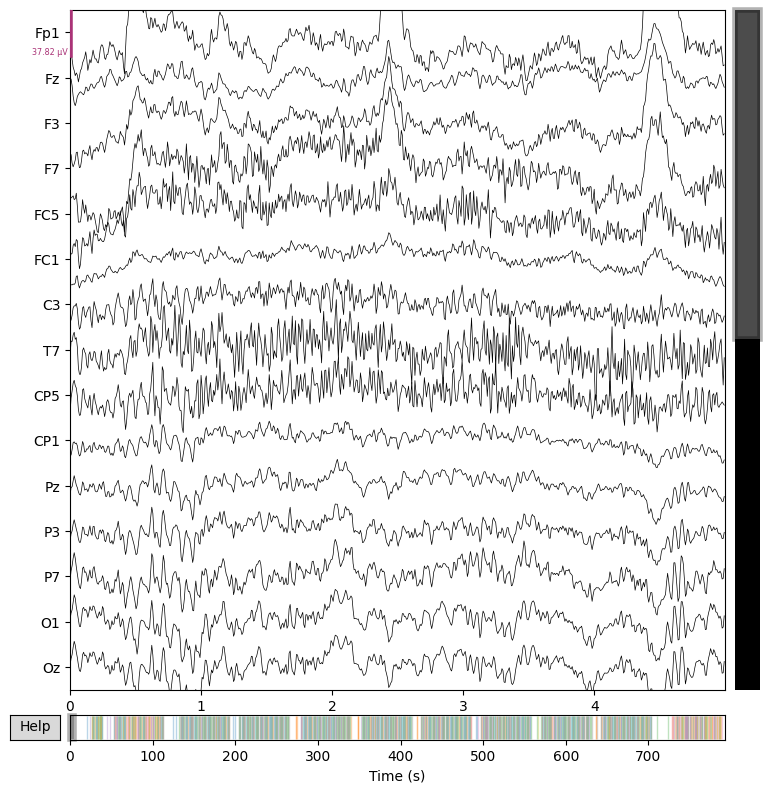

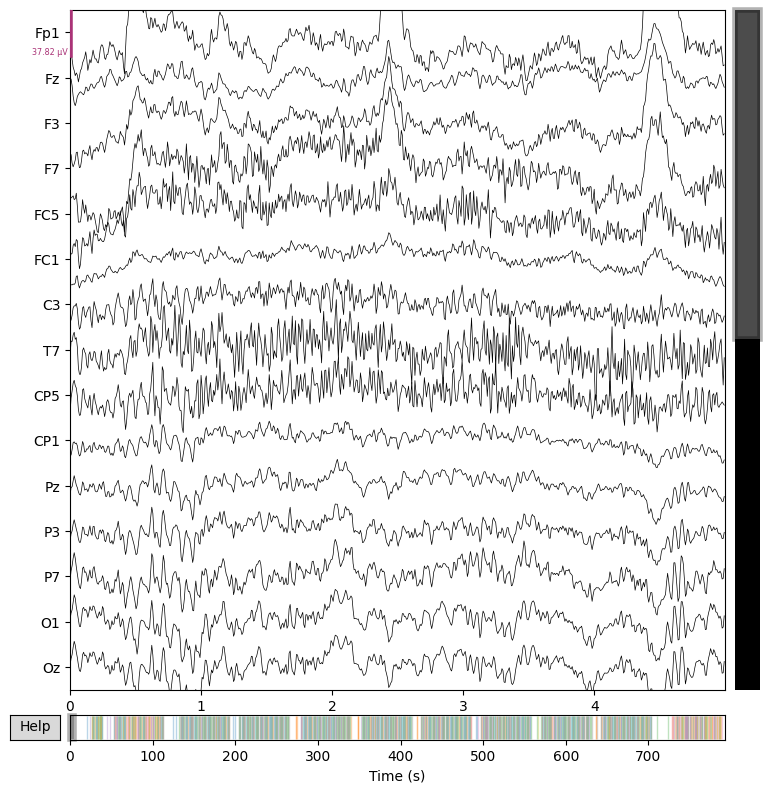

In [7]:
# 1. Set the montage (Standard 10-20 system for electrode locations)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

# 2. Filtering (Standard for EEG: 0.1Hz to 40Hz)
raw.filter(l_freq=0.1, h_freq=40.0)

# 3. Plotting the data to inspect for noise
raw.plot(n_channels=15, duration=5, scalings='auto')